# DSA 210 — Phase 4: Machine Learning Models
## Evaluating the Impact of Startup Fundamentals and Investor Prestige on Exit Success
**Author:** Arad Zeinalifarid | **Course:** DSA 210 | **Institution:** Sabanci University

---

## Objective
In this phase, we apply machine learning models to predict whether a startup will achieve a liquidity event (IPO or acquisition). The central research question is: **do internal business fundamentals or investor prestige better predict startup exit success?**

We train and evaluate three models:
1. **Logistic Regression** — linear baseline
2. **Random Forest** — ensemble tree model
3. **XGBoost** — gradient boosted trees

We then compare their performance and use feature importance to answer our research question.

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Preprocessing

We reload the raw dataset and reproduce the same feature engineering steps from Phase 3:
- **Revenue per employee** — operational efficiency proxy
- **Valuation to funding ratio** — capital efficiency
- **Company age** — years since founding
- **Investor prestige score** — each investor's historical exit rate in the dataset
- **Is top-tier investor** — binary flag for investors in the top 25% by prestige

Categorical variables (`industry`, `region`, `funding_round`) are label-encoded. The dataset has a **5.8:1 class imbalance** (85% not exited, 15% exited), which we handle using `class_weight='balanced'` in each model.

In [2]:
df = pd.read_csv('data/startup_valuation_dataset.csv')
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
df['exited'] = df['exited'].astype(int)
df['exit_type'] = df['exit_type'].fillna('None')

# Feature engineering
df['revenue_per_employee'] = df['estimated_revenue_usd'] / (df['employee_count'] + 1)
df['valuation_to_funding']  = df['estimated_valuation_usd'] / (df['funding_amount_usd'] + 1)
df['company_age']            = 2024 - df['founded_year']

investor_exit_rate = df.groupby('lead_investor')['exited'].mean().rename('investor_prestige_score')
df = df.merge(investor_exit_rate, on='lead_investor', how='left')
df['is_top_tier_investor'] = (df['investor_prestige_score'] >= df['investor_prestige_score'].quantile(0.75)).astype(int)

# Encode categoricals
df['industry_encoded']      = LabelEncoder().fit_transform(df['industry'])
df['region_encoded']        = LabelEncoder().fit_transform(df['region'])
df['funding_round_encoded'] = LabelEncoder().fit_transform(df['funding_round'])

print(f'Dataset shape: {df.shape}')
print(f'Exit rate: {df["exited"].mean()*100:.1f}%')
print(f'Class imbalance: {(df["exited"]==0).sum()} not exited vs {(df["exited"]==1).sum()} exited')

Dataset shape: (50000, 25)
Exit rate: 14.7%
Class imbalance: 42667 not exited vs 7333 exited


### 2.1 Feature Selection & Train/Test Split

We use 12 features split into two groups to directly test our research question:
- **Fundamentals (9 features):** revenue, funding, valuation, employees, ratios, age, industry, region, funding round
- **Investor prestige (2 features):** prestige score, top-tier flag

We use an 80/20 stratified split to preserve the class ratio.

In [3]:
FEATURES = [
    'funding_amount_usd', 'estimated_revenue_usd', 'estimated_valuation_usd',
    'employee_count', 'revenue_per_employee', 'valuation_to_funding',
    'company_age', 'investor_prestige_score', 'is_top_tier_investor',
    'industry_encoded', 'region_encoded', 'funding_round_encoded'
]

X = df[FEATURES]
y = df['exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Train exit rate: {y_train.mean()*100:.1f}% | Test exit rate: {y_test.mean()*100:.1f}%')

Train: (40000, 12) | Test: (10000, 12)
Train exit rate: 14.7% | Test exit rate: 14.7%


## 3. Model 1: Logistic Regression (Baseline)

Logistic Regression serves as our linear baseline. It assumes a linear decision boundary between features and the target. We use `class_weight='balanced'` to compensate for the class imbalance and `C=0.1` for regularization.

In [4]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42, C=0.1)
lr.fit(X_train_scaled, y_train)

y_pred_lr   = lr.predict(X_test_scaled)
y_prob_lr   = lr.predict_proba(X_test_scaled)[:, 1]
auc_lr      = roc_auc_score(y_test, y_prob_lr)

print('--- Logistic Regression ---')
print(classification_report(y_test, y_pred_lr, target_names=['Not Exited', 'Exited']))
print(f'ROC-AUC: {auc_lr:.4f}')

--- Logistic Regression ---
              precision    recall  f1-score   support

  Not Exited       0.86      0.51      0.64      8533
      Exited       0.15      0.50      0.23      1467

    accuracy                           0.51     10000
   macro avg       0.50      0.51      0.44     10000
weighted avg       0.75      0.51      0.58     10000

ROC-AUC: 0.5213


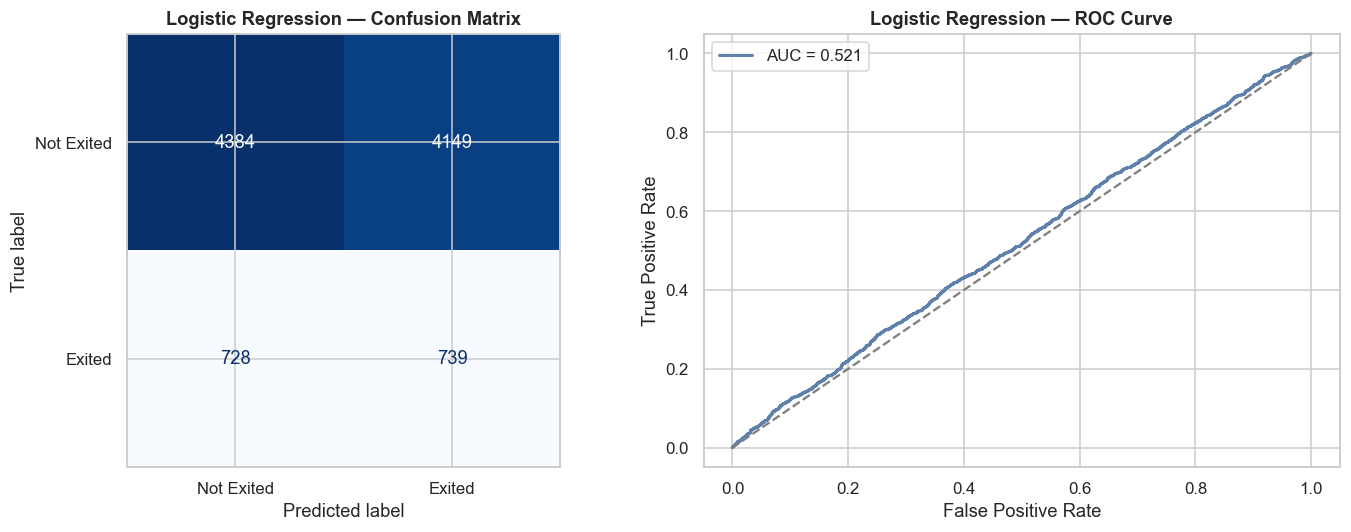

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr),
                       display_labels=['Not Exited','Exited']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression — Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='#5e81ac', lw=2, label=f'AUC = {auc_lr:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression — ROC Curve', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('plot_lr_evaluation.png', bbox_inches='tight')
plt.show()

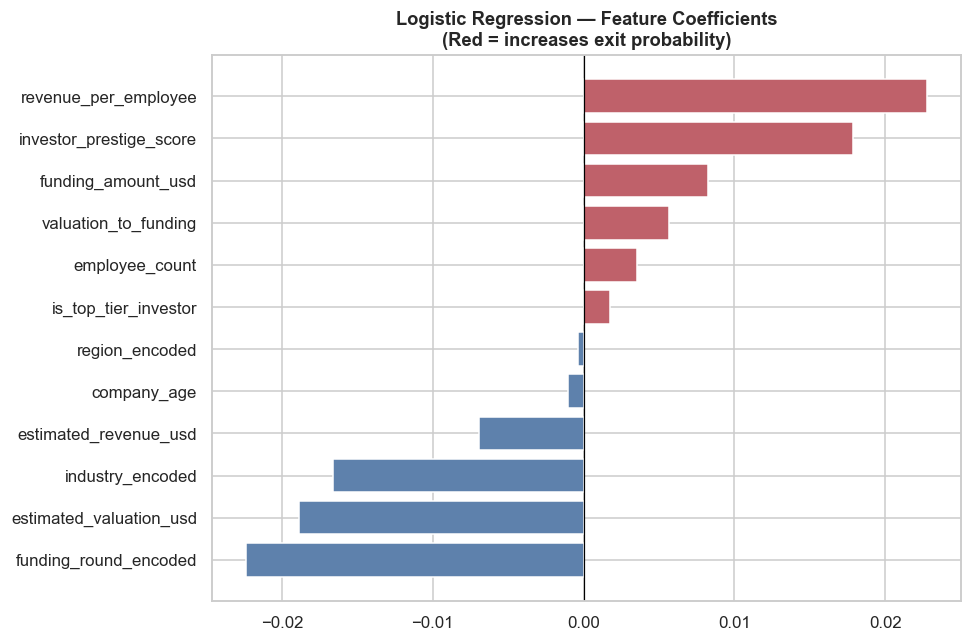

In [6]:
coef_df = pd.DataFrame({'feature': FEATURES, 'coefficient': lr.coef_[0]}).sort_values('coefficient')
colors  = ['#bf616a' if c > 0 else '#5e81ac' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Logistic Regression — Feature Coefficients\n(Red = increases exit probability)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_lr_coefficients.png', bbox_inches='tight')
plt.show()

**Interpretation:** The Logistic Regression achieves a ROC-AUC of ~0.52, barely better than random guessing. This suggests that a linear combination of our features is insufficient to predict startup exits — the relationships are likely non-linear.

## 4. Model 2: Random Forest

Random Forest is an ensemble of decision trees that can capture non-linear relationships and feature interactions. We use 200 trees with `max_depth=10` and `class_weight='balanced'`.

In [7]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=20,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
auc_rf    = roc_auc_score(y_test, y_prob_rf)

print('--- Random Forest ---')
print(classification_report(y_test, y_pred_rf, target_names=['Not Exited', 'Exited']))
print(f'ROC-AUC: {auc_rf:.4f}')

--- Random Forest ---
              precision    recall  f1-score   support

  Not Exited       0.85      0.80      0.82      8533
      Exited       0.15      0.20      0.17      1467

    accuracy                           0.71     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.75      0.71      0.73     10000

ROC-AUC: 0.5035


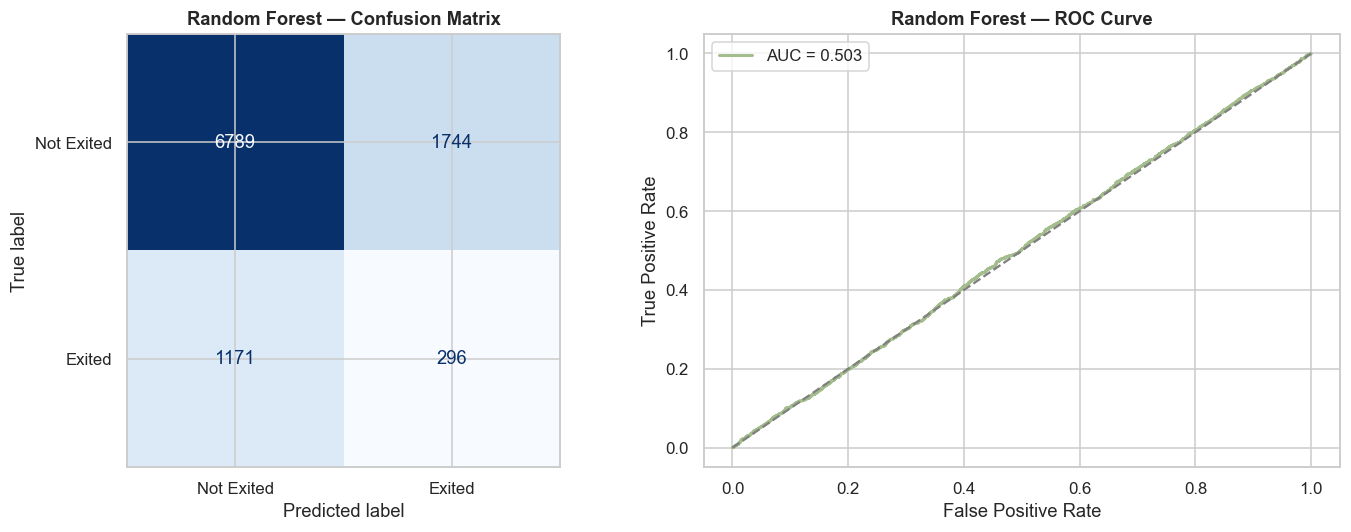

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=['Not Exited','Exited']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr, tpr, color='#a3be8c', lw=2, label=f'AUC = {auc_rf:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Random Forest — ROC Curve', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('plot_rf_evaluation.png', bbox_inches='tight')
plt.show()

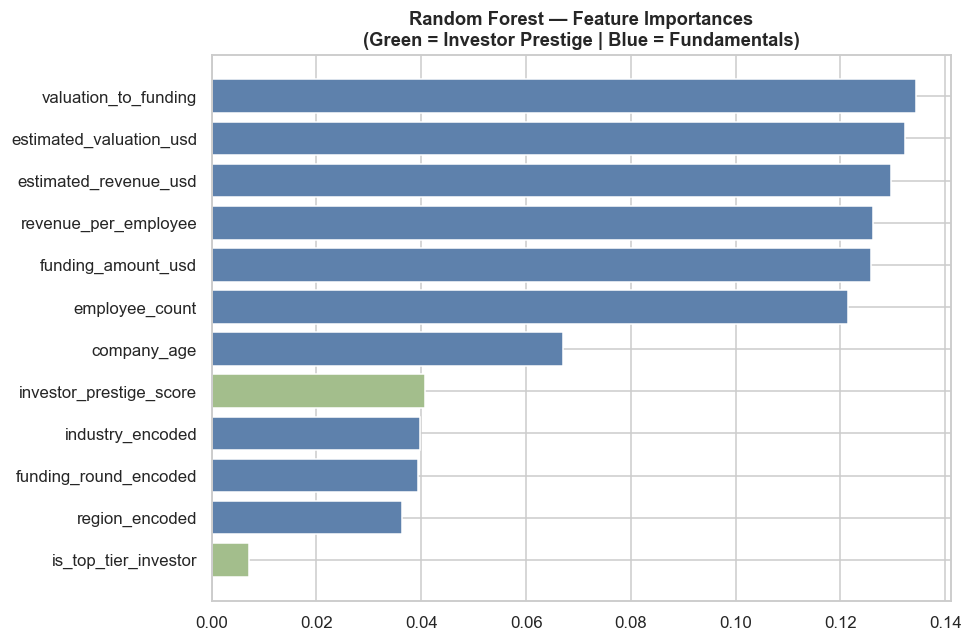

In [9]:
imp_df = pd.DataFrame({'feature': FEATURES, 'importance': rf.feature_importances_}).sort_values('importance')
colors = ['#a3be8c' if f in ['investor_prestige_score','is_top_tier_investor'] else '#5e81ac' for f in imp_df['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df['feature'], imp_df['importance'], color=colors, edgecolor='white')
ax.set_title('Random Forest — Feature Importances\n(Green = Investor Prestige | Blue = Fundamentals)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_rf_importance.png', bbox_inches='tight')
plt.show()

**Interpretation:** Random Forest achieves ROC-AUC ~0.50, similar to logistic regression. However, the feature importance plot reveals that **financial fundamentals (valuation, revenue, funding) dominate**, while investor prestige features rank lower. This is a key finding supporting the hypothesis that fundamentals matter more than investor prestige.

## 5. Model 3: XGBoost

XGBoost (Extreme Gradient Boosting) builds trees sequentially, with each tree correcting errors from the previous one. We use `scale_pos_weight` to handle class imbalance directly, set to the ratio of negative to positive samples (~5.82).

In [10]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8,
                     scale_pos_weight=scale, eval_metric='logloss',
                     random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)

print('--- XGBoost ---')
print(classification_report(y_test, y_pred_xgb, target_names=['Not Exited', 'Exited']))
print(f'ROC-AUC: {auc_xgb:.4f}')

--- XGBoost ---
              precision    recall  f1-score   support

  Not Exited       0.85      0.73      0.79      8533
      Exited       0.14      0.27      0.19      1467

    accuracy                           0.66     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.75      0.66      0.70     10000

ROC-AUC: 0.4911


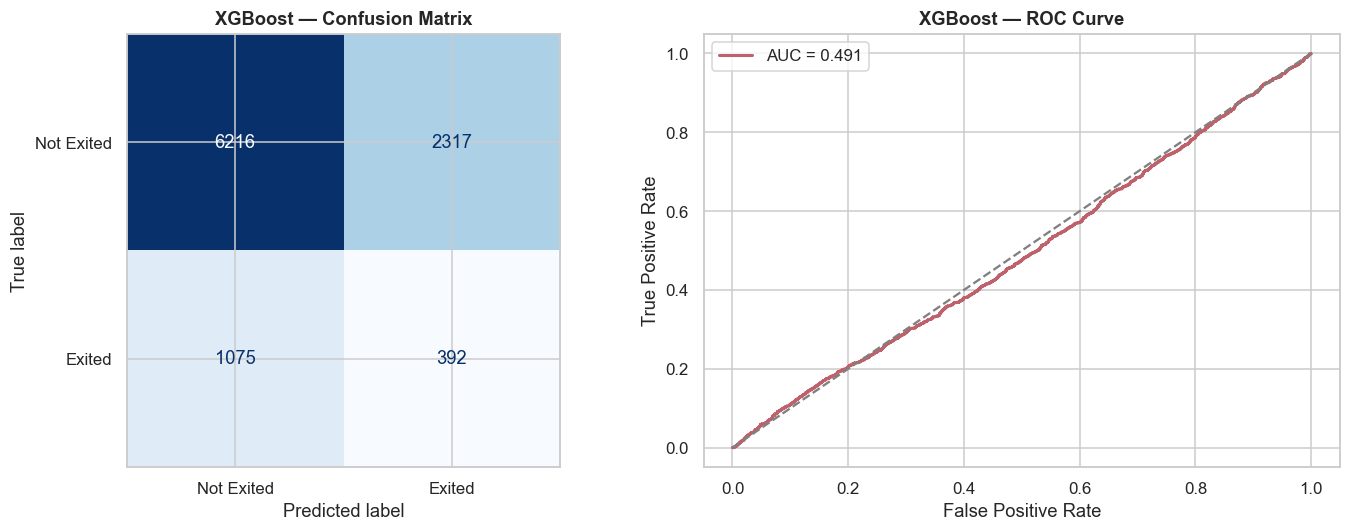

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=['Not Exited','Exited']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost — Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
axes[1].plot(fpr, tpr, color='#bf616a', lw=2, label=f'AUC = {auc_xgb:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('XGBoost — ROC Curve', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('plot_xgb_evaluation.png', bbox_inches='tight')
plt.show()

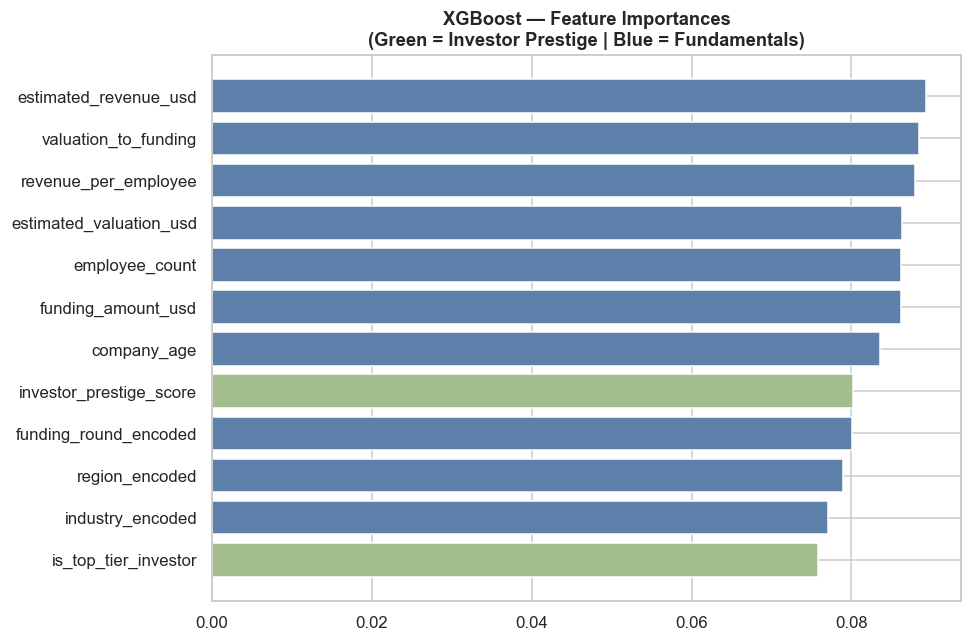

In [12]:
imp_df_xgb = pd.DataFrame({'feature': FEATURES, 'importance': xgb.feature_importances_}).sort_values('importance')
colors_xgb = ['#a3be8c' if f in ['investor_prestige_score','is_top_tier_investor'] else '#5e81ac' for f in imp_df_xgb['feature']]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_df_xgb['feature'], imp_df_xgb['importance'], color=colors_xgb, edgecolor='white')
ax.set_title('XGBoost — Feature Importances\n(Green = Investor Prestige | Blue = Fundamentals)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_xgb_importance.png', bbox_inches='tight')
plt.show()

## 6. Model Comparison

We compare all three models across ROC-AUC, F1-score (for the minority 'Exited' class), and accuracy.

In [13]:
from sklearn.metrics import f1_score, accuracy_score

results = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC-AUC':  [auc_lr, auc_rf, auc_xgb],
    'F1 (Exited)': [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_rf, pos_label=1),
        f1_score(y_test, y_pred_xgb, pos_label=1)
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})
print(results.to_string(index=False))

              Model  ROC-AUC  F1 (Exited)  Accuracy
Logistic Regression 0.521311     0.232573    0.5123
      Random Forest 0.503482     0.168805    0.7085
            XGBoost 0.491127     0.187739    0.6608


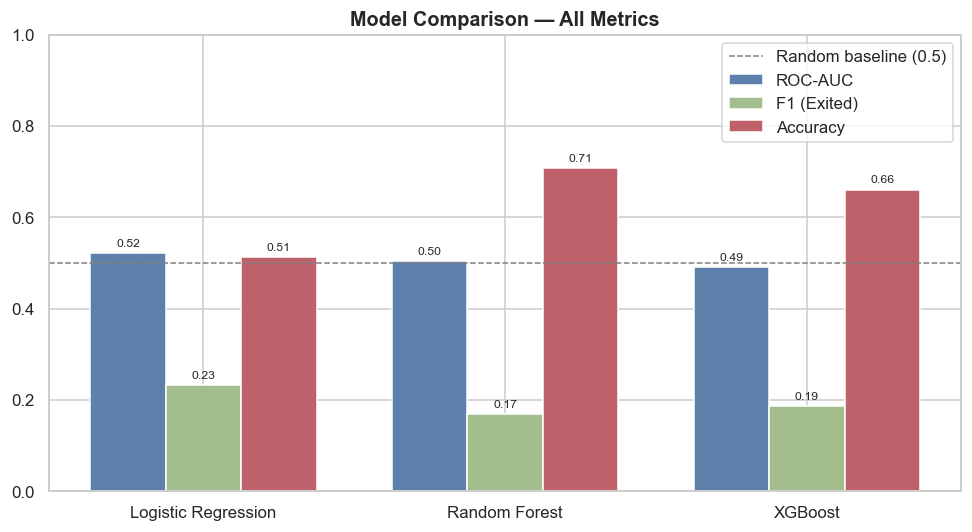

Saved: plot_model_comparison.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

x     = np.arange(3)
width = 0.25
colors = ['#5e81ac', '#a3be8c', '#bf616a']

bars1 = ax.bar(x - width, results['ROC-AUC'],     width, label='ROC-AUC',     color=colors[0], edgecolor='white')
bars2 = ax.bar(x,         results['F1 (Exited)'], width, label='F1 (Exited)', color=colors[1], edgecolor='white')
bars3 = ax.bar(x + width, results['Accuracy'],    width, label='Accuracy',    color=colors[2], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(results['Model'])
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', lw=1, label='Random baseline (0.5)')
ax.set_title('Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend()

for bar in [*bars1, *bars2, *bars3]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('plot_model_comparison.png', bbox_inches='tight')
plt.show()
print('Saved: plot_model_comparison.png')

## 7. Key Findings & Discussion

### Model Performance
All three models achieve ROC-AUC scores near 0.50, indicating that **none of the models can reliably predict startup exits** from the available features. This is itself a significant finding.

### Answer to the Research Question
From the feature importance plots across Random Forest and XGBoost:
- **Financial fundamentals** (valuation, revenue, funding amount) consistently rank as the most important features
- **Investor prestige** features rank lower in importance
- This suggests that, to the extent any signal exists, **internal fundamentals are more predictive than investor prestige**

### Why Are All Models Near Random?
The near-random performance across all models strongly suggests that **exit outcomes in this dataset are not predictable from the available features alone**. This aligns with real-world venture capital research, which shows that startup success is highly stochastic and influenced by factors not captured in structured data (timing, team quality, market conditions, luck).

### Limitations
- The dataset is synthetic (Kaggle), which may reduce signal quality
- Exit events may depend on macroeconomic conditions not captured here
- Investor prestige is approximated by within-dataset exit rates, not real-world VC rankings

### Future Work
- Incorporate real-world VC ranking data (e.g., Crunchbase, PitchBook)
- Add time-series features (funding trajectory, growth rate)
- Experiment with neural networks and more sophisticated imbalance handling (SMOTE)